# Logistische Regression
**Statistical Modeling - Session 10**

Von der linearen Regression zur Klassifikation: warum die Gerade scheitert, wie
die logistische Funktion hilft, und wie wir Koeffizienten und Entscheidungsgrenze
lesen.

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.special import expit          # logistische Funktion 1/(1+e^-z)
from sklearn.datasets import make_classification

rng = 2

## 1. Warum nicht einfach lineare Regression? (1 Pradiktor)

Wir passen sowohl eine **Gerade** (OLS) als auch eine **logistische Kurve** an eine
binaere Zielgroesse an. Die Gerade verlaesst den Bereich $[0,1]$ und liefert damit
keine sinnvollen Wahrscheinlichkeiten.

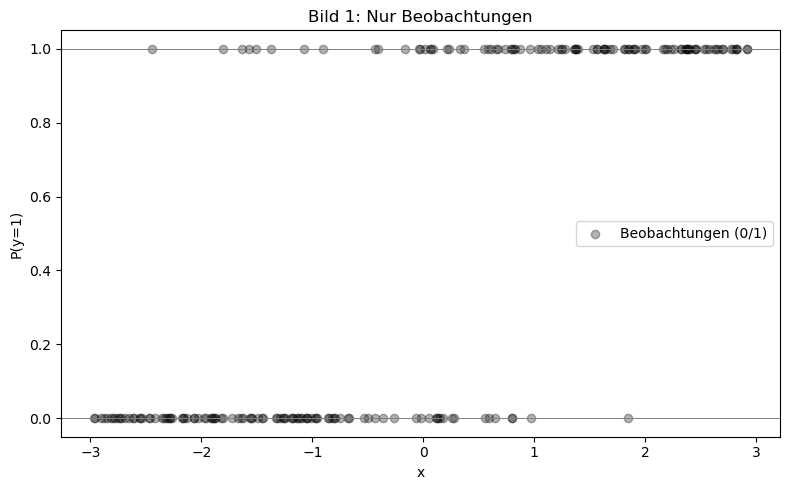

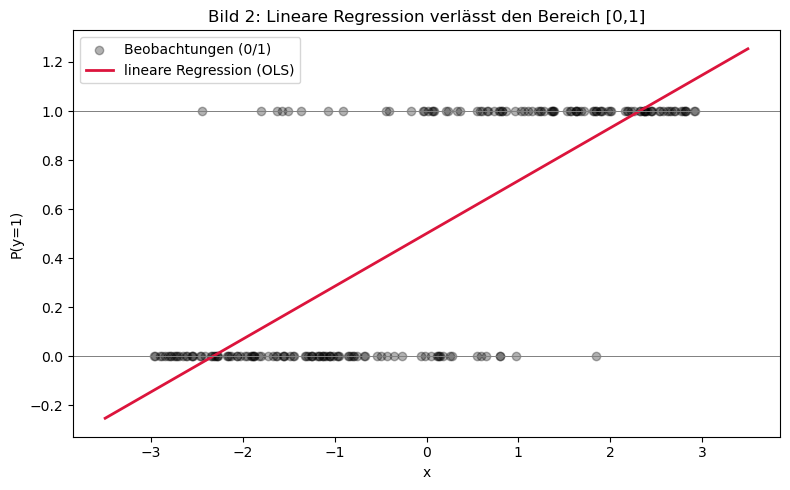

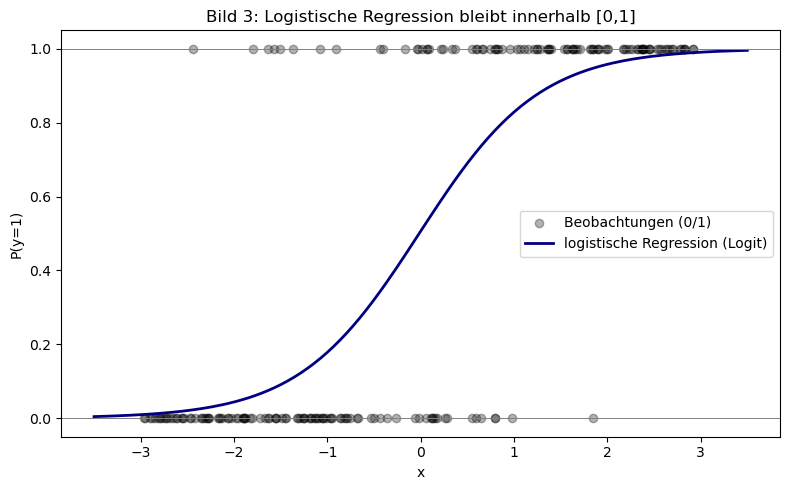

In [5]:
# Daten generieren
rng = 42  # Beispiel-Seed
np.random.seed(rng)
x = np.random.uniform(-3, 3, 200)
p_true = expit(1.5 * x)
y = np.random.binomial(1, p_true)

# Modelle fitten
ols = sm.OLS(y, sm.add_constant(x)).fit()
logit = sm.Logit(y, sm.add_constant(x)).fit(disp=0)

# Vorhersagewerte berechnen
xs = np.linspace(-3.5, 3.5, 200)
Xs = sm.add_constant(xs)

# --- BILD 1: Nur die Beobachtungspunkte ---
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.3, color="black", label="Beobachtungen (0/1)")
plt.axhline(0, color="gray", lw=0.7)
plt.axhline(1, color="gray", lw=0.7)
plt.xlabel("x")
plt.ylabel("P(y=1)")
plt.title("Bild 1: Nur Beobachtungen")
plt.legend()
plt.tight_layout()
plt.savefig("bild1logit.png", dpi=300, bbox_inches="tight")
plt.show()

# --- BILD 2: Punkte + Lineare Regression (OLS) ---
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.3, color="black", label="Beobachtungen (0/1)")
plt.plot(
    xs,
    ols.predict(Xs),
    color="crimson",
    lw=2,
    label="lineare Regression (OLS)",
)
plt.axhline(0, color="gray", lw=0.7)
plt.axhline(1, color="gray", lw=0.7)
plt.xlabel("x")
plt.ylabel("P(y=1)")
plt.title("Bild 2: Lineare Regression verlässt den Bereich [0,1]")
plt.legend()
plt.tight_layout()
plt.savefig("bild2logit.png", dpi=300, bbox_inches="tight")
plt.show()

# --- BILD 3: Punkte + Logistische Regression (Logit) ---
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.3, color="black", label="Beobachtungen (0/1)")
plt.plot(
    xs,
    logit.predict(Xs),
    color="navy",
    lw=2,
    label="logistische Regression (Logit)",
)
plt.axhline(0, color="gray", lw=0.7)
plt.axhline(1, color="gray", lw=0.7)
plt.xlabel("x")
plt.ylabel("P(y=1)")
plt.title("Bild 3: Logistische Regression bleibt innerhalb [0,1]")
plt.legend()
plt.tight_layout()
plt.savefig("bild3logit.png", dpi=300, bbox_inches="tight")
plt.show()

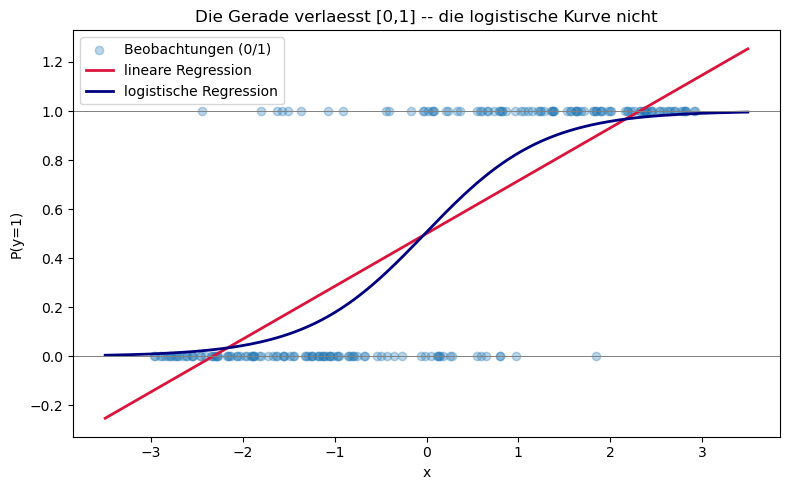

In [4]:
np.random.seed(rng)
x = np.random.uniform(-3, 3, 200)
p_true = expit(1.5 * x)
y = np.random.binomial(1, p_true)

ols   = sm.OLS(y, sm.add_constant(x)).fit()
logit = sm.Logit(y, sm.add_constant(x)).fit(disp=0)

xs = np.linspace(-3.5, 3.5, 200)
Xs = sm.add_constant(xs)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.3, label="Beobachtungen (0/1)")
plt.plot(xs, ols.predict(Xs),   color="crimson", lw=2, label="lineare Regression")
plt.plot(xs, logit.predict(Xs), color="navy",    lw=2, label="logistische Regression")
plt.axhline(0, color="gray", lw=0.7); plt.axhline(1, color="gray", lw=0.7)
plt.xlabel("x"); plt.ylabel("P(y=1)")
plt.title("Die Gerade verlaesst [0,1] -- die logistische Kurve nicht")
plt.legend(); plt.tight_layout(); plt.show()

## 2. Die logistische Funktion

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Sie bildet ganz $\mathbb{R}$ auf $(0,1)$ ab. Bei $z = 0$ ist $\sigma = 0.5$.

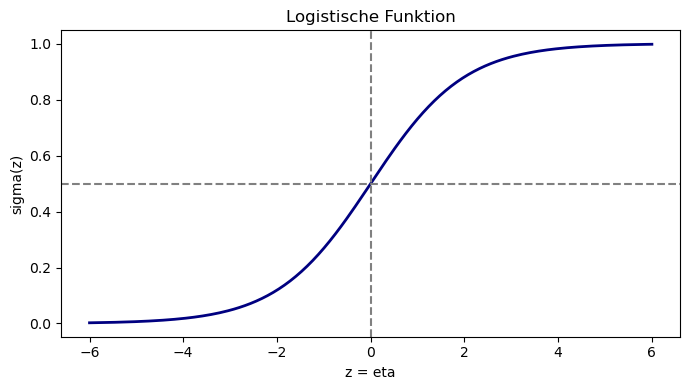

In [3]:
z = np.linspace(-6, 6, 200)
plt.figure(figsize=(7, 4))
plt.plot(z, expit(z), color="navy", lw=2)
plt.axhline(0.5, color="gray", ls="--"); plt.axvline(0, color="gray", ls="--")
plt.xlabel("z = eta"); plt.ylabel("sigma(z)")
plt.title("Logistische Funktion")
plt.tight_layout(); plt.show()

## 3. Zwei Pradiktoren -- Modell mit statsmodels

`sm.Logit` liefert eine ausfuehrliche `summary()` -- ideal, um Vorzeichen,
Signifikanz (`P>|z|`) und die Koeffizienten auf der Log-Odds-Skala abzulesen.

In [4]:
X, yc = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.0, flip_y=0.15, random_state=rng)
df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = yc

Xc = sm.add_constant(df[["x1", "x2"]])
modell = sm.Logit(df["y"], Xc).fit(disp=0)
print(modell.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  300
Model:                          Logit   Df Residuals:                      297
Method:                           MLE   Df Model:                            2
Date:                Sun, 07 Jun 2026   Pseudo R-squ.:                  0.4460
Time:                        22:46:09   Log-Likelihood:                -115.14
converged:                       True   LL-Null:                       -207.84
Covariance Type:            nonrobust   LLR p-value:                 5.493e-41
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4644      0.315      1.475      0.140      -0.153       1.082
x1             1.8908      0.199      9.510      0.000       1.501       2.280
x2            -0.5969      0.200     -2.987      0.0

**Lesehilfe:** `coef` ist $\beta$ auf der Log-Odds-Skala. Ein positives
$\beta$ erhoeht $P(y=1)$, ein negatives senkt sie. `P>|z|` ist der p-Wert.

## 4. Koeffizienten als Odds-Ratios

$e^{\beta_j}$ ist das Odds-Ratio: pro Einheit $x_j$ multipliziert sich die Odds
fuer $y=1$ mit diesem Faktor.

In [5]:
or_tab = pd.DataFrame({
    "Koeffizient (beta)": modell.params,
    "Odds-Ratio (e^beta)": np.exp(modell.params),
})
print(or_tab.round(3))

       Koeffizient (beta)  Odds-Ratio (e^beta)
const               0.464                1.591
x1                  1.891                6.625
x2                 -0.597                0.551


## 5. Eine Vorhersage von Hand nachrechnen

Rechnung: $\eta = \beta_0 + \beta_1 x_1 + \beta_2 x_2$, dann
$p = \sigma(\eta)$.

In [6]:
b0, b1, b2 = modell.params
x1v, x2v = 1.0, 0.5

eta = b0 + b1 * x1v + b2 * x2v
p = expit(eta)
p_modell = modell.predict(np.array([[1.0, x1v, x2v]]))[0]

print(f"eta              = {eta:.3f}")
print(f"P(y=1) von Hand  = {p:.3f}")
print(f"P(y=1) vom Modell= {p_modell:.3f}")
print("Klasse bei Schwelle 0.5:", int(p >= 0.5))

eta              = 2.057
P(y=1) von Hand  = 0.887
P(y=1) vom Modell= 0.887
Klasse bei Schwelle 0.5: 1


## 6. Die Entscheidungsgrenze

Klassifiziert wird $\hat y = 1$, wenn $p \geq 0.5 \Leftrightarrow \eta \geq 0$.
Da $\eta$ linear ist, ist die Grenze eine **Gerade**:
$$x_2 = -\frac{\beta_0 + \beta_1 x_1}{\beta_2}.$$

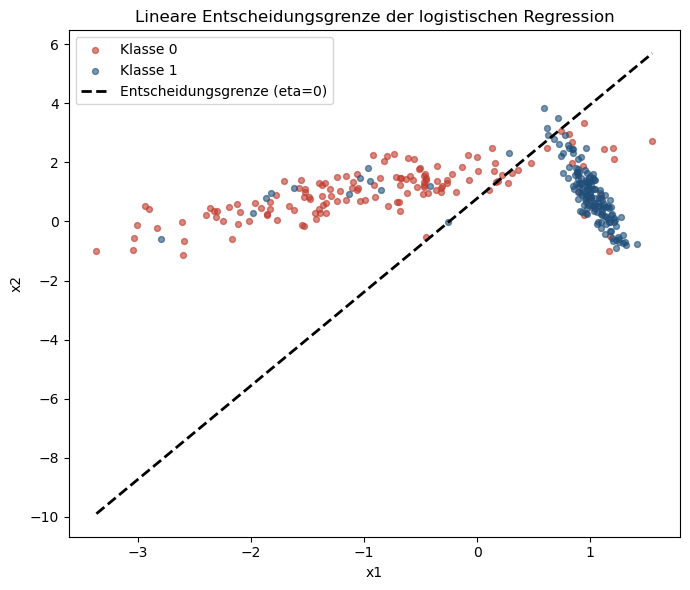

In [7]:
plt.figure(figsize=(7, 6))
for klasse, farbe in [(0, "#C0392B"), (1, "#1F4E79")]:
    m = df["y"] == klasse
    plt.scatter(df.x1[m], df.x2[m], s=18, alpha=0.6, label=f"Klasse {klasse}", color=farbe)

x1_range = np.linspace(df.x1.min(), df.x1.max(), 100)
x2_grenze = -(b0 + b1 * x1_range) / b2
plt.plot(x1_range, x2_grenze, "k--", lw=2, label="Entscheidungsgrenze (eta=0)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("Lineare Entscheidungsgrenze der logistischen Regression")
plt.legend(); plt.tight_layout(); plt.show()

## Zum Mitnehmen

- Lineare Regression scheitert bei binaerem $y$ -- die logistische Funktion haelt
  die Vorhersage in $(0,1)$.
- Auf der **Log-Odds-Skala** bleibt das Modell linear; $e^{\beta_j}$ ist das
  Odds-Ratio.
- Geschaetzt wird per **Maximum Likelihood** (= Log-Loss minimieren).
- Die **Entscheidungsgrenze** ist linear.

> **Klausur-Bezug:** $P(y=1)$ fuer ein gegebenes $x$ berechnen, ein $e^{\beta}$
> interpretieren und die Grenze ($\eta = 0$) bestimmen -- siehe Uebung 2.